# Feature simplification and model selection

This notebook asks which original patient characteristics contribute useful
information, how many are needed by each model family, and which completed
candidate performs best on validation. All feature work remains confined to
the training cohort.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import StratifiedKFold

from src.config import (
    CANDIDATE_FEATURES, FEATURE_DISPLAY_NAMES, MODEL_COMPLEXITY_ORDER,
    MODEL_FAMILIES, PRACTICAL_MARGIN, SEED, SUBSET_SIZES,
)
from src.data import create_fixed_split, load_support2
from src.evaluation import population_baseline, score_exit_probabilities
from src.feature_selection import cross_fitted_feature_simplification
from src.modelling import (
    cross_validate_candidate, default_indicator_features, fit_candidate,
    predict_candidate,
)

FIGURES = PROJECT_ROOT / 'results' / 'figures'
TABLES = PROJECT_ROOT / 'results' / 'tables'
DEVELOPMENT = PROJECT_ROOT / 'results' / 'development'
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

In [2]:
df = load_support2()
train_df, validation_df, _ = create_fixed_split(df)
train_model = train_df.loc[
    train_df['days_to_hospital_exit'] > 3
].set_index('patient_id').copy()
validation_model = validation_df.loc[
    validation_df['days_to_hospital_exit'] > 3
].set_index('patient_id').copy()
for cohort in (train_model, validation_model):
    cohort['event'] = np.where(cohort['in_hospital_death'].eq(1), 2, 1)

fold_labels = (
    train_model['event'].astype(str) + '_'
    + pd.qcut(train_model['days_to_hospital_exit'], q=5, duplicates='drop').astype(str)
)
patient_folds = list(StratifiedKFold(
    5, shuffle=True, random_state=SEED
).split(train_model, fold_labels))
with (DEVELOPMENT / 'best_all_feature_parameters.json').open() as file:
    best_parameters = json.load(file)
tuning_results = pd.read_csv(DEVELOPMENT / 'all_feature_tuning.csv')

## Cross-fitted grouped importance and feature count

Each outer training fold is divided once into an internal fitting part and an
internal ranking part. Original variables are permuted in the ranking part,
and top-feature subsets are then scored on the held-out outer fold. This
prevents the same held-out outcomes from both defining and assessing a ranking
without nesting hyperparameter tuning.

In [3]:
importance_frames = []
subset_frames = []
for family in MODEL_FAMILIES:
    print('Feature simplification:', family)
    importance, subsets = cross_fitted_feature_simplification(
        train_model, CANDIDATE_FEATURES, family, best_parameters[family],
        patient_folds, SUBSET_SIZES,
    )
    importance_frames.append(importance)
    subset_frames.append(subsets)

feature_importance = pd.concat(importance_frames, ignore_index=True)
subset_folds = pd.concat(subset_frames, ignore_index=True)
feature_importance.to_csv(DEVELOPMENT / 'cross_fitted_feature_importance.csv', index=False)
subset_folds.to_csv(DEVELOPMENT / 'cross_fitted_subset_folds.csv', index=False)

importance_summary = (
    feature_importance.groupby(['model', 'feature'])['importance']
    .agg(Mean='mean', SD='std', Count='count').reset_index()
)
importance_summary['SE'] = importance_summary['SD'] / np.sqrt(importance_summary['Count'])
importance_summary['Label'] = importance_summary['feature'].map(FEATURE_DISPLAY_NAMES)

subset_summary = subset_folds.groupby(['model', 'n_features'])['mean_daily_brier'].agg(
    Mean='mean', SD='std', Count='count',
).reset_index()
subset_summary['SE'] = subset_summary['SD'] / np.sqrt(subset_summary['Count'])

selection_rows = []
for family, values in subset_summary.groupby('model'):
    best = values.loc[values['Mean'].idxmin()]
    threshold = best['Mean'] + best['SE']
    selected = values.loc[values['Mean'].le(threshold)].sort_values('n_features').iloc[0]
    selection_rows.append({
        'model': family, 'selected_n_features': int(selected['n_features']),
        'minimum_score': best['Mean'], 'selection_threshold': threshold,
        'selected_score': selected['Mean'],
    })
selected_sizes = pd.DataFrame(selection_rows).set_index('model')
display(subset_summary.round(5))
display(selected_sizes.round(5))

Feature simplification: Multinomial logistic regression


Feature simplification: Histogram gradient boosting


,model,n_features,Mean,SD,Count,SE
0,Histogram gradient boosting,5,0.14385,0.00124,5,0.00055
1,Histogram gradient boosting,10,0.13920,0.00149,5,0.00066
2,Histogram gradient boosting,15,0.13701,0.00208,5,0.00093
3,Histogram gradient boosting,20,0.13685,0.00187,5,0.00084
4,Histogram gradient boosting,28,0.13658,0.00213,5,0.00095
5,Multinomial logistic regression,5,0.14456,0.00221,5,0.00099
6,Multinomial logistic regression,10,0.14392,0.00206,5,0.00092
7,Multinomial logistic regression,15,0.14209,0.00172,5,0.00077
8,Multinomial logistic regression,20,0.14168,0.00204,5,0.00091
9,Multinomial logistic regression,28,0.14093,0.00136,5,0.00061


,selected_n_features,minimum_score,selection_threshold,selected_score
model,,,,
Histogram gradient boosting,15,0.13658,0.13753,0.13701
Multinomial logistic regression,28,0.14093,0.14154,0.14093


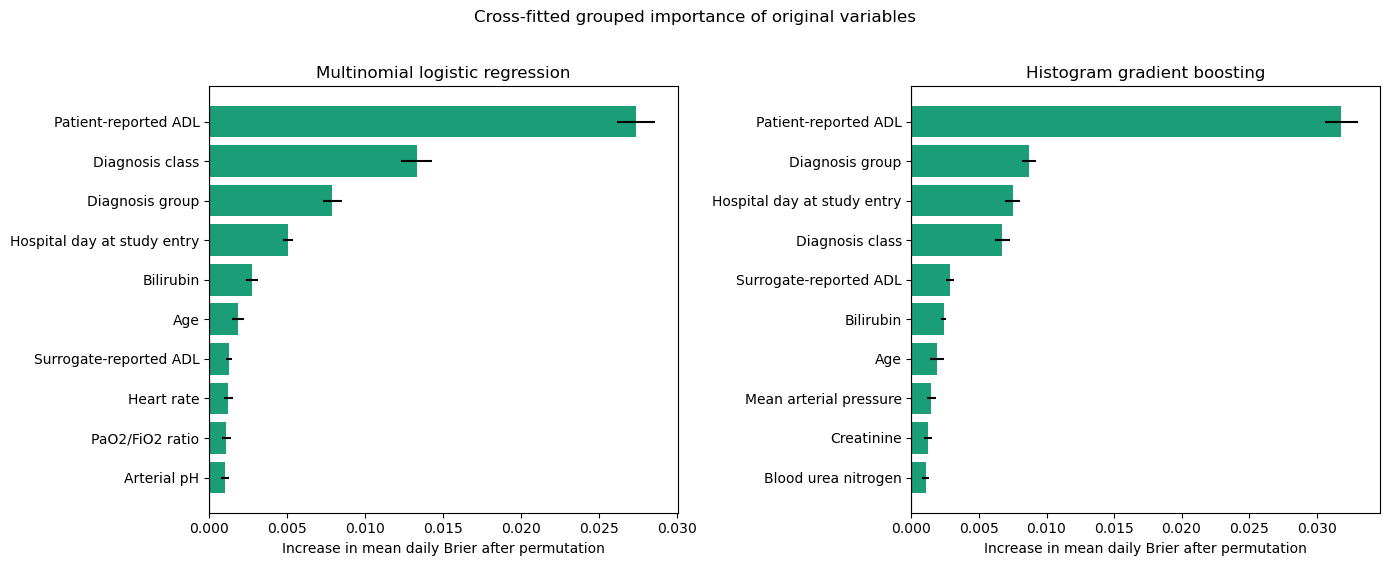

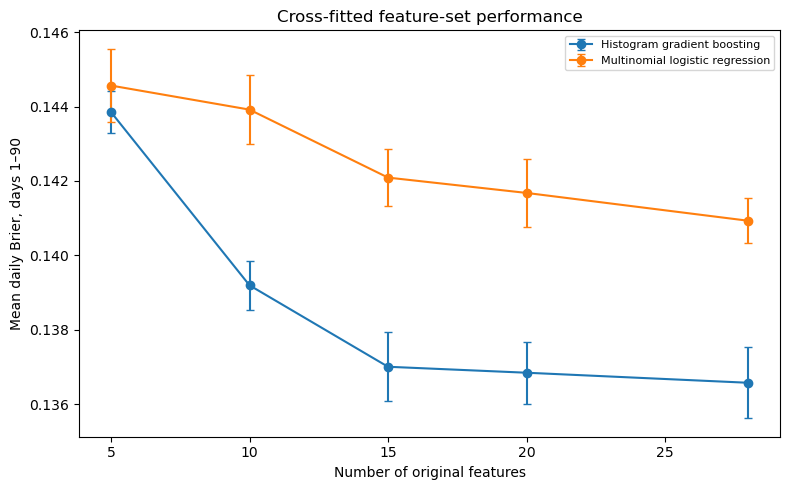

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, family in zip(axes, MODEL_FAMILIES):
    top = (
        importance_summary.loc[importance_summary['model'].eq(family)]
        .sort_values('Mean', ascending=False).head(10).sort_values('Mean')
    )
    ax.barh(top['Label'], top['Mean'], xerr=top['SE'], color='#1b9e77')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set(title=family, xlabel='Increase in mean daily Brier after permutation')
fig.suptitle('Cross-fitted grouped importance of original variables', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / 'feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for family, values in subset_summary.groupby('model'):
    ax.errorbar(values['n_features'], values['Mean'], yerr=values['SE'],
                marker='o', capsize=3, label=family)
ax.set(xlabel='Number of original features',
       ylabel='Mean daily Brier, days 1–90',
       title='Cross-fitted feature-set performance')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'feature_subset_performance.png', dpi=160, bbox_inches='tight')
plt.show()


Patient-reported ADL makes the largest predictive contribution for both
models, followed by diagnosis, hospital day at study entry, and selected
physiological or laboratory measurements. Importance is model-specific and
predictive, not a causal or biological effect.

The cross-fitted one-standard-error rule retains 15 features for HGB and all 28
for logistic regression. The 15-feature HGB score remains within 0.00043 of its
all-feature minimum, whereas logistic regression does not support a reduced
feature count under the same rule.

## Limited retuning of simplified candidates

Only the three strongest all-feature configurations are reconsidered for the
reduced HGB subset. This checks whether simplification changes the preferred
model complexity without repeating the full tuning search.


In [5]:
candidate_features = {}
retuning_rows = []
for family in MODEL_FAMILIES:
    ranking = (
        importance_summary.loc[importance_summary['model'].eq(family)]
        .sort_values('Mean', ascending=False)['feature'].tolist()
    )
    selected_n = int(selected_sizes.loc[family, 'selected_n_features'])
    candidate_features[family] = ranking[:selected_n]
    family_tuning = (
        tuning_results.loc[tuning_results['model'].eq(family)]
        .sort_values('rank').head(3 if selected_n < len(CANDIDATE_FEATURES) else 1)
    )
    for _, row in family_tuning.iterrows():
        parameters = json.loads(row['parameters'])
        _, folds = cross_validate_candidate(
            train_model, candidate_features[family], family, parameters,
            patient_folds,
            indicator_features=default_indicator_features(candidate_features[family]),
        )
        retuning_rows.append({
            'model': family, 'parameters': json.dumps(parameters, sort_keys=True),
            'mean_daily_brier': folds['mean_daily_brier'].mean(),
            'fold_sd': folds['mean_daily_brier'].std(),
        })

retuning_results = pd.DataFrame(retuning_rows).sort_values(
    ['model', 'mean_daily_brier']
)
retuning_results['rank'] = retuning_results.groupby('model').cumcount() + 1
final_parameters = {
    family: json.loads(retuning_results.loc[
        retuning_results['model'].eq(family)
        & retuning_results['rank'].eq(1), 'parameters'
    ].iloc[0])
    for family in MODEL_FAMILIES
}
display(retuning_results.round(5))
retuning_results.to_csv(DEVELOPMENT / 'limited_retuning.csv', index=False)

,model,parameters,mean_daily_brier,fold_sd,rank
1,Histogram gradient boosting,"{""l2_regularization"": 10.0, ""learning_rate"": 0...",0.13661,0.00178,1
2,Histogram gradient boosting,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.13736,0.00140,2
3,Histogram gradient boosting,"{""l2_regularization"": 10.0, ""learning_rate"": 0...",0.13757,0.00234,3
0,Multinomial logistic regression,"{""C"": 100.0}",0.14093,0.00136,1


## Patient-reported ADL value and missingness

Four HGB conditions isolate the observed patient-reported ADL value and its
explicit missingness flag. All other predictors, missingness indicators,
folds, and HGB settings remain unchanged. Surrogate-reported ADL remains an
ordinary covariate, so the comparison estimates the additional contribution
of the patient-reported field.

,Mean,SD,Count,SE,In-hospital death,Live discharge
condition,,,,,,
Full: value + missingness,0.13658,0.00213,5,0.00095,0.12807,0.14508
Missingness only,0.13690,0.00213,5,0.00095,0.12837,0.14544
Value only,0.14191,0.00267,5,0.00119,0.13167,0.15214
Neither,0.14419,0.00323,5,0.00144,0.13333,0.15506


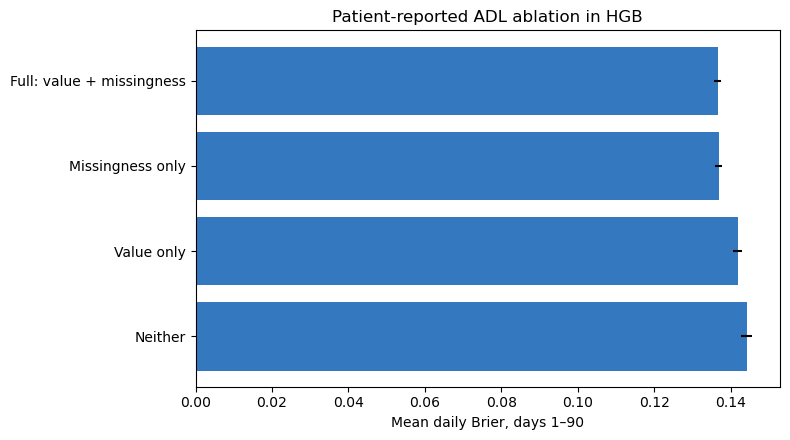

In [6]:
adl_data = train_model.copy()
adl_data['adl_patient_reported_missing'] = (
    adl_data['adl_patient_reported'].isna().astype(float)
)
all_indicators = default_indicator_features(CANDIDATE_FEATURES)
without_adl = [name for name in CANDIDATE_FEATURES if name != 'adl_patient_reported']
without_adl_indicators = [
    name for name in all_indicators if name != 'adl_patient_reported'
]
adl_conditions = {
    'Full: value + missingness': (
        CANDIDATE_FEATURES, all_indicators,
    ),
    'Value only': (
        CANDIDATE_FEATURES, without_adl_indicators,
    ),
    'Missingness only': (
        without_adl + ['adl_patient_reported_missing'], without_adl_indicators,
    ),
    'Neither': (
        without_adl, without_adl_indicators,
    ),
}
adl_fold_frames = []
adl_metric_frames = []
hgb_parameters = best_parameters['Histogram gradient boosting']
for condition, (features, indicators) in adl_conditions.items():
    metrics, folds = cross_validate_candidate(
        adl_data, features, 'Histogram gradient boosting', hgb_parameters,
        patient_folds, indicator_features=indicators,
    )
    metrics['condition'] = condition
    folds['condition'] = condition
    adl_metric_frames.append(metrics)
    adl_fold_frames.append(folds)

adl_folds = pd.concat(adl_fold_frames, ignore_index=True)
adl_metrics = pd.concat(adl_metric_frames, ignore_index=True)
adl_summary = adl_folds.groupby('condition')['mean_daily_brier'].agg(
    Mean='mean', SD='std', Count='count',
)
adl_summary['SE'] = adl_summary['SD'] / np.sqrt(adl_summary['Count'])
event_scores = (
    adl_metrics.loc[adl_metrics['metric'].eq('Mean daily Brier')]
    .groupby(['condition', 'event'])['value'].mean().unstack('event')
)
adl_display = adl_summary.join(event_scores).sort_values('Mean')
display(adl_display.round(5))
adl_display.to_csv(TABLES / 'adl_ablation.csv')

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_values = adl_summary.sort_values('Mean', ascending=False)
ax.barh(plot_values.index, plot_values['Mean'], xerr=plot_values['SE'],
        color='#3478bf')
ax.set(xlabel='Mean daily Brier, days 1–90',
       title='Patient-reported ADL ablation in HGB')
fig.tight_layout()
fig.savefig(FIGURES / 'adl_ablation.png', dpi=160, bbox_inches='tight')
plt.show()

Removing the explicit patient-reported ADL indicator increases mean daily Brier
from 0.13658 to 0.14191 even when the imputed value remains. Retaining only the
indicator gives 0.13690, while removing both value and indicator gives 0.14419.
The missingness pattern therefore carries most of this field's predictive signal
in this dataset. Possible explanations include response ability, documentation,
workflow, or site practice; the result is not causal.

## Validation comparison and locked specification

Each completed family is fitted once on the full training cohort and assessed on
validation. The primary rule selects the lowest validation mean daily Brier.
Within an absolute margin of 0.002, the less complex pipeline is preferred only
when the predictive difference is considered negligible.

In [7]:
validation_metric_frames = []
validation_rows = []
for family in MODEL_FAMILIES:
    features = candidate_features[family]
    parameters = final_parameters[family]
    preprocessor, model = fit_candidate(
        train_model, features, family, parameters,
        indicator_features=default_indicator_features(features),
    )
    probabilities = predict_candidate(
        preprocessor, model, validation_model, features, family,
    )
    metrics, score = score_exit_probabilities(probabilities, validation_model)
    metrics['model'] = family
    validation_metric_frames.append(metrics)
    validation_rows.append({
        'model': family, 'n_features': len(features),
        'mean_daily_brier': score,
    })

baseline_probabilities = population_baseline(
    train_model[['days_to_hospital_exit', 'event']], len(validation_model)
)
baseline_metrics, baseline_score = score_exit_probabilities(
    baseline_probabilities, validation_model,
)
baseline_metrics['model'] = 'Population baseline'
validation_metric_frames.append(baseline_metrics)

validation_summary = pd.DataFrame(validation_rows).sort_values('mean_daily_brier')
best_score = validation_summary['mean_daily_brier'].min()
near_best = validation_summary.loc[
    validation_summary['mean_daily_brier'] <= best_score + PRACTICAL_MARGIN
].copy()
near_best['complexity'] = near_best['model'].map(MODEL_COMPLEXITY_ORDER)
selected_family = near_best.sort_values(
    ['complexity', 'mean_daily_brier', 'n_features']
).iloc[0]['model']

validation_metrics = pd.concat(validation_metric_frames, ignore_index=True)
display(validation_summary.round(5))
display(validation_metrics.loc[
    validation_metrics['metric'].isin(['Brier', 'AUC'])
    & validation_metrics['horizon'].eq(30)
].pivot_table(index=['model', 'event'], columns='metric', values='value').round(4))
validation_summary.to_csv(TABLES / 'validation_model_comparison.csv', index=False)
validation_metrics.to_csv(TABLES / 'validation_metrics.csv', index=False)

locked_specification = {
    'model_family': selected_family,
    'features': candidate_features[selected_family],
    'parameters': final_parameters[selected_family],
    'indicator_features': default_indicator_features(candidate_features[selected_family]),
    'selection_metric': 'Mean daily Brier over days 1-90',
    'practical_margin': PRACTICAL_MARGIN,
}
with (DEVELOPMENT / 'locked_model.json').open('w') as file:
    json.dump(locked_specification, file, indent=2)

display(pd.DataFrame({
    'Item': ['Model family', 'Original features', 'Validation mean daily Brier',
             'Practical margin'],
    'Value': [
        selected_family, len(locked_specification['features']),
        validation_summary.set_index('model').loc[selected_family, 'mean_daily_brier'],
        PRACTICAL_MARGIN,
    ],
}))
display(pd.DataFrame({
    'Feature': [FEATURE_DISPLAY_NAMES[name] for name in locked_specification['features']]
}))
display(pd.DataFrame(
    list(locked_specification['parameters'].items()),
    columns=['Parameter', 'Value'],
))

,model,n_features,mean_daily_brier
1,Histogram gradient boosting,15,0.13142
0,Multinomial logistic regression,28,0.13419


metric                                                AUC   Brier
model                           event                            
Histogram gradient boosting     In-hospital death  0.8217  0.1255
                                Live discharge     0.8415  0.1482
Multinomial logistic regression In-hospital death  0.8129  0.1258
                                Live discharge     0.8316  0.1532
Population baseline             In-hospital death  0.5000  0.1637
                                Live discharge     0.5000  0.2198

,Item,Value
0,Model family,Histogram gradient boosting
1,Original features,15
2,Validation mean daily Brier,0.131424
3,Practical margin,0.002


,Feature
0,Patient-reported ADL
1,Diagnosis group
2,Hospital day at study entry
3,Diagnosis class
4,Surrogate-reported ADL
5,Bilirubin
6,Age
7,Mean arterial pressure
8,Creatinine
9,Blood urea nitrogen


,Parameter,Value
0,l2_regularization,10.00
1,learning_rate,0.05
2,max_iter,200.00
3,max_leaf_nodes,15.00
4,min_samples_leaf,50.00


HGB obtains validation mean daily Brier 0.13142, compared with 0.13419
for logistic regression. The HGB improvement of 0.00277 exceeds the
prespecified 0.002 practical margin, so HGB is selected with 15 original
features.

The locked model family, features, preprocessing inputs, and hyperparameters are
carried forward unchanged. The held-out test set has not contributed to fitting,
tuning, feature simplification, validation comparison, or model selection.
